# ShopIQ — Customer Churn Prediction

---


## 1. Project Initialization

### 1.1 Problem Statement
E-commerce and subscription-based businesses lose significant revenue when customers stop using their
service ("churn"). Identifying customers who are *likely* to churn ahead of time lets a business step in
with retention offers, support, or discounts before the customer actually leaves.

This project builds a machine learning model that predicts whether a given customer will **churn (leave
the service) or not**, using their account, billing, and service-usage details. The model will later be
plugged into the ShopIQ backend (Flask REST API) and surfaced on the React dashboard as a churn-risk
score for each customer.

### 1.2 ML Problem Type
- **Classification** (binary classification)
- Target variable: `Churn` → **Yes (1)** or **No (0)**

### 1.3 Objective
Build and evaluate a classification model that predicts customer churn with strong **recall on the
churn class** (catching as many at-risk customers as possible is more valuable to the business than
raw accuracy, since missing a churner is costlier than a false alarm), while keeping overall performance
solid enough for production use in the ShopIQ dashboard.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('../Dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.shape

(7043, 21)

## 2. Dataset Understanding

- **Dataset Name:** Telco Customer Churn (IBM Sample Dataset)
- **Dataset Source:** IBM / Kaggle — [WA_Fn-UseC_-Telco-Customer-Churn.csv](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
- **Number of Rows:** 7,043
- **Number of Columns:** 21
- **Target Variable:** `Churn` (Yes / No)
- **Feature Columns:** 19 predictive features + `customerID` (identifier, dropped before training)

### Feature Description

| Feature | Description |
|---|---|
| customerID | Unique identifier for each customer (dropped, not predictive) |
| gender | Customer's gender (Male/Female) |
| SeniorCitizen | Whether the customer is a senior citizen (1) or not (0) |
| Partner | Whether the customer has a partner (Yes/No) |
| Dependents | Whether the customer has dependents (Yes/No) |
| tenure | Number of months the customer has stayed with the company |
| PhoneService | Whether the customer has phone service (Yes/No) |
| MultipleLines | Whether the customer has multiple lines (Yes/No/No phone service) |
| InternetService | Customer's internet service type (DSL/Fiber optic/No) |
| OnlineSecurity | Whether the customer has online security add-on (Yes/No/No internet service) |
| OnlineBackup | Whether the customer has online backup add-on (Yes/No/No internet service) |
| DeviceProtection | Whether the customer has device protection add-on (Yes/No/No internet service) |
| TechSupport | Whether the customer has tech support add-on (Yes/No/No internet service) |
| StreamingTV | Whether the customer has streaming TV (Yes/No/No internet service) |
| StreamingMovies | Whether the customer has streaming movies (Yes/No/No internet service) |
| Contract | Contract term (Month-to-month/One year/Two year) |
| PaperlessBilling | Whether the customer uses paperless billing (Yes/No) |
| PaymentMethod | Payment method (Electronic check/Mailed check/Bank transfer/Credit card) |
| MonthlyCharges | Amount charged to the customer monthly (float) |
| TotalCharges | Total amount charged over the customer's tenure (numeric, stored as text) |
| **Churn** | **Target: whether the customer churned (Yes/No)** |


In [2]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# TotalCharges is stored as text in the raw file because 11 new customers (tenure = 0)
# have a blank string instead of a number. Converting it reveals these missing values.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.isnull().sum()[df.isnull().sum() > 0]

TotalCharges    11
dtype: int64

In [5]:
df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Categorical vs numerical features
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('customerID')
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical features ({len(categorical_cols)}):\n{categorical_cols}\n")
print(f"Numerical features ({len(numerical_cols)}):\n{numerical_cols}")

Categorical features (16):
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

Numerical features (4):
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


/tmp/ipykernel_610/1487169959.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.tolist()


In [8]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

**Observation:** The target is **imbalanced** — about 73% of customers did *not* churn vs 27% who did.
This will influence both the choice of algorithm (favoring models/parameters that handle class weight)
and the evaluation metric (accuracy alone would be misleading).

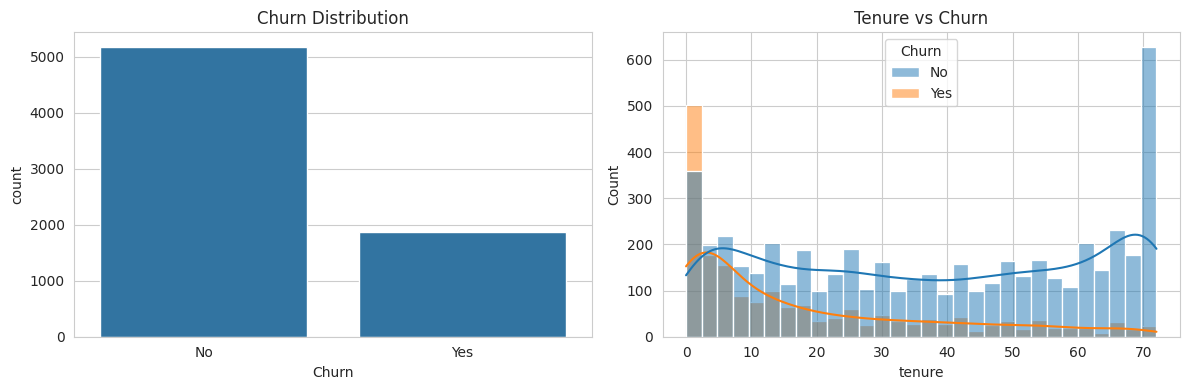

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x='Churn', ax=ax[0])
ax[0].set_title('Churn Distribution')
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True, ax=ax[1])
ax[1].set_title('Tenure vs Churn')
plt.tight_layout()
plt.show()

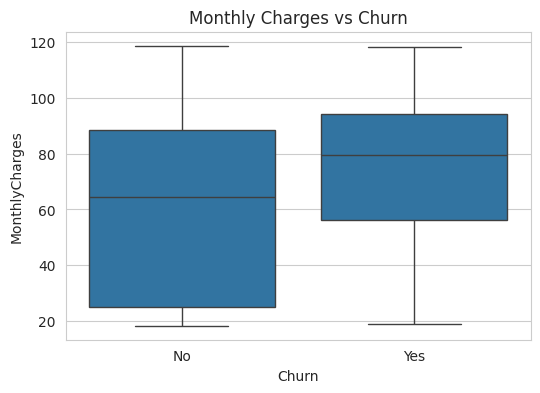

In [10]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges vs Churn')
plt.show()

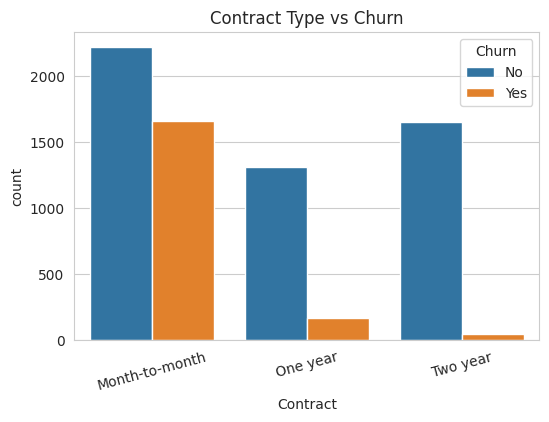

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Contract Type vs Churn')
plt.xticks(rotation=15)
plt.show()

**Key early insights:**
- Customers with **short tenure** and **month-to-month contracts** churn far more often.
- Higher **MonthlyCharges** is associated with higher churn.
- Customers without add-ons like `OnlineSecurity` / `TechSupport` churn more — these will likely be
  strong predictive features.


## 3. Project Planning

### 3.1 Data Preprocessing Steps
1. Drop `customerID` (identifier, not predictive).
2. Convert `TotalCharges` to numeric; impute the 11 missing values (all `tenure == 0`, new customers) with 0 or median.
3. Encode the binary target `Churn` → 1 (Yes) / 0 (No).
4. Encode categorical features using **One-Hot Encoding** (all categorical columns are nominal, low-cardinality).
5. Scale numerical features (`tenure`, `MonthlyCharges`, `TotalCharges`) — required for distance/linear based models, optional for tree-based models.
6. Train/test split (80/20), **stratified** on `Churn` to preserve class balance.

### 3.2 Feature Engineering
- Derive `AvgMonthlySpend = TotalCharges / (tenure + 1)` to normalize spend by tenure.
- Bucket `tenure` into groups (0–12, 13–24, 25–48, 49+ months) to capture non-linear tenure effects.
- Combine the six service add-on columns into a single `TotalServicesSubscribed` count.
- Flag `IsMonthToMonth` (1/0) since this contract type is the strongest early churn signal.

### 3.3 Machine Learning Algorithm(s)
| Algorithm | Reason for Selection |
|---|---|
| **Logistic Regression** | Simple, interpretable baseline; coefficients show which features drive churn risk — useful for the dashboard's "why is this customer at risk" explanation. |
| **Random Forest Classifier** | Handles mixed categorical/numerical features well, robust to outliers, captures non-linear feature interactions (e.g., tenure × contract type), and gives feature importances. Also matches the model already used in the ShopIQ backend service. |
| **Gradient Boosting (XGBoost/LightGBM)** | Typically the strongest performer on tabular churn datasets; used as a stretch goal to compare against Random Forest. |

Class imbalance will be handled via `class_weight='balanced'` (Logistic Regression, Random Forest) and/or
`scale_pos_weight` (XGBoost), rather than naive oversampling, to avoid overfitting to duplicated minority
samples.

### 3.4 Evaluation Metrics
Because catching potential churners matters more than raw accuracy on this imbalanced dataset:
- **Recall** (of the churn class) — primary metric, minimizes missed at-risk customers.
- **Precision** — to keep false alarms (and unnecessary retention offers) manageable.
- **F1-score** — balances precision and recall.
- **ROC-AUC** — measures overall ranking quality of churn-risk scores, which is what will be shown on the dashboard.
- Confusion Matrix — for a clear breakdown of correct/incorrect predictions per class.


## 4. Next Steps (Day 20 — Implementation)
- Build the full preprocessing pipeline (`ColumnTransformer` + `Pipeline`).
- Train and compare Logistic Regression, Random Forest, and Gradient Boosting.
- Tune hyperparameters (GridSearchCV / RandomizedSearchCV) on the best-performing model.
- Evaluate on the held-out test set using the metrics above.
- Save the final pipeline as `.pkl` and push the notebook, model, and documentation to GitHub.
